# Notebook 04 — Baseline Model: TF-IDF + SVM

Fase CRISP-DM : Modeling (baseline)
Input : dataset_annotated_final.csv (2.266 baris)
Output : dataset_split.csv, predictions_svm_revisi.csv, eval_svm_revisi.csv, confusion_svm_revisi.png, f1_per_aspek_svm.csv


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Path


In [11]:
# from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

BASE       = "/content/drive/MyDrive/TA_ACSC_EWA"
FINAL_PATH = f"{BASE}/03_anotasi/data/dataset_annotated_final.csv"
OUT_DIR    = f"{BASE}/04_Modeling/tfidf_svm"
SPLIT_PATH = f"{BASE}/05_modeling/dataset_split.csv"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Muat Dataset Final (NB03)


In [4]:
ann = pd.read_csv(FINAL_PATH)
print(f"Baris ACSC: {len(ann)} | Ulasan unik: {ann['review_id'].nunique()}")
print("\nSentimen:\n", ann['sentiment'].value_counts())
print("\nAspek:\n", ann['aspect_category'].value_counts())


Baris ACSC: 2266 | Ulasan unik: 2031

Sentimen:
 sentiment
positif    1167
negatif     967
netral      132
Name: count, dtype: int64

Aspek:
 aspect_category
Kemudahan Penggunaan    1198
Keandalan Sistem         464
Kecepatan Pencairan      296
Biaya/Potongan           196
Customer Service         112
Name: count, dtype: int64


---
## STEP 2: Pembagian Data — GroupShuffleSplit (80:20, level review_id)

Ulasan multi-aspek menghasilkan beberapa baris berteks sama. Pembagian pada level baris berisiko menempatkan teks identik di train dan test sekaligus (data leakage). GroupShuffleSplit membagi pada level review_id sehingga seluruh baris satu ulasan berada pada subset yang sama. Dua langkah: kunci 20% test terlebih dahulu, lalu pisahkan validasi (untuk NB05) dari sisanya. Hasil split disimpan ke dataset_split.csv agar NB05 memakai pembagian yang sama persis.


In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tv_idx, te_idx = next(gss.split(ann, groups=ann['review_id']))
train_val, test = ann.iloc[tv_idx].copy(), ann.iloc[te_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=185/len(train_val), random_state=RANDOM_STATE)
tr_idx, va_idx = next(gss2.split(train_val, groups=train_val['review_id']))
train, val = train_val.iloc[tr_idx].copy(), train_val.iloc[va_idx].copy()

smap={}
for r in train['review_id']: smap[r]='train'
for r in val['review_id']:   smap[r]='val'
for r in test['review_id']:  smap[r]='test'
ann['split']=ann['review_id'].map(smap)
ann.to_csv(SPLIT_PATH, index=False)
print(f"train {len(train)} | val {len(val)} | test {len(test)}  -> {SPLIT_PATH}")


train 1627 | val 185 | test 454  -> /content/drive/MyDrive/TA_ACSC_EWA/05_modeling/dataset_split.csv


### 3.1 Verifikasi Anti-Leakage

In [8]:
tr,va,te = set(train['review_id']),set(val['review_id']),set(test['review_id'])
assert len(tr&te)==0 and len(tr&va)==0 and len(va&te)==0, "review_id bocor!"
assert len(set(train['review_text_clean'])&set(test['review_text_clean']))==0, "teks bocor!"
print("review_id train n test :", len(tr&te), "(harus 0)")
print("teks_clean train n test:", len(set(train['review_text_clean'])&set(test['review_text_clean'])), "(harus 0)")
for nm,d in [('train',train),('val',val),('test',test)]:
    p=d['sentiment'].value_counts(normalize=True)*100
    print(f"  {nm:<6}: pos {p.get('positif',0):.1f}% neg {p.get('negatif',0):.1f}% net {p.get('netral',0):.1f}%")


review_id train n test : 0 (harus 0)
teks_clean train n test: 0 (harus 0)
  train : pos 51.5% neg 42.5% net 6.0%
  val   : pos 44.3% neg 49.2% net 6.5%
  test  : pos 54.4% neg 40.5% net 5.1%


## 4. TF-IDF + SVM

LinearSVC dengan GridSearchCV

Input sentence-pair "teks [SEP] aspek" — identik dengan format input IndoBERT agar kedua model menjawab soal yang sama. TF-IDF memakai sublinear TF, min_df 2, dan batas atas kosakata max_features 10.000 (ukuran kosakata aktual dilaporkan di output). SVM dilatih pada gabungan train+val karena pemilihan hyperparameter memakai validasi silang 5-fold internal (skor f1_macro).


In [9]:
def buat_X(d): return (d['review_text_clean'].astype(str)+' [SEP] '+d['aspect_category'].astype(str)).values
X_tv=buat_X(pd.concat([train,val])); y_tv=pd.concat([train,val])['sentiment'].values
X_te,y_te=buat_X(test),test['sentiment'].values

vec=TfidfVectorizer(sublinear_tf=True,min_df=2)
Xtv=vec.fit_transform(X_tv); Xte=vec.transform(X_te)
grid=GridSearchCV(LinearSVC(class_weight='balanced',max_iter=5000),
                  {'C':[0.01,0.1,1.0]},scoring='f1_macro',cv=5,n_jobs=-1)
grid.fit(Xtv,y_tv)
print("Best C:",grid.best_params_['C'],"| CV Macro-F1:",round(grid.best_score_,4))
clf=grid.best_estimator_


Best C: 1.0 | CV Macro-F1: 0.836


## 5. Evaluasi Test


In [12]:
pred=clf.predict(Xte); labels=['positif','negatif','netral']
macro=f1_score(y_te,pred,average='macro',labels=labels); acc=accuracy_score(y_te,pred)
print(f"Macro-F1: {macro:.4f} | Accuracy: {acc:.4f}\n")
print(classification_report(y_te,pred,labels=labels,digits=4))
test_out=test.copy(); test_out['y_pred']=pred; test_out['correct']=(test_out['sentiment']==pred)
test_out.to_csv(f"{OUT_DIR}/predictions_svm_revisi.csv",index=False)
pd.DataFrame([{'model':'TF-IDF+SVM','macro_f1':macro,'accuracy':acc,
               'n_train':len(train)+len(val),'n_test':len(test)}]).to_csv(f"{OUT_DIR}/eval_svm_revisi.csv",index=False)


Macro-F1: 0.8454 | Accuracy: 0.8789

              precision    recall  f1-score   support

     positif     0.9057    0.8947    0.9002       247
     negatif     0.8519    0.8750    0.8633       184
      netral     0.8095    0.7391    0.7727        23

    accuracy                         0.8789       454
   macro avg     0.8557    0.8363    0.8454       454
weighted avg     0.8790    0.8789    0.8788       454



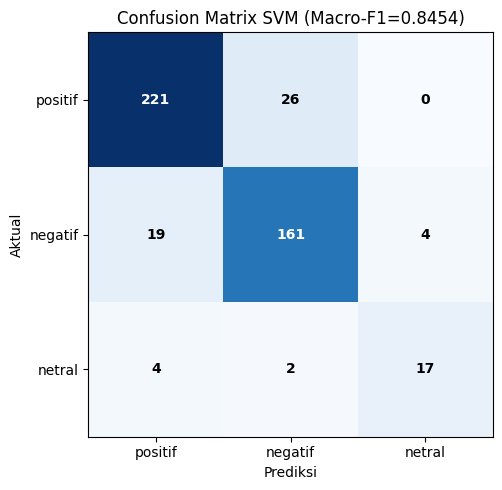

In [13]:
cm=confusion_matrix(y_te,pred,labels=labels)
fig,ax=plt.subplots(figsize=(6,5)); ax.imshow(cm,cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3)); ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual'); ax.set_title(f'Confusion Matrix SVM (Macro-F1={macro:.4f})')
for i in range(3):
    for j in range(3):
        ax.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black',fontweight='bold')
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_svm_revisi.png",dpi=150,bbox_inches='tight'); plt.show()


---
## STEP 6: Evaluasi Per-Aspek

Metrik agregat dapat menyembunyikan variasi antar aspek, sehingga F1 dihitung per kategori aspek.


In [14]:
def f1_per_aspek(dfp):
    rows=[]
    for asp in dfp['aspect_category'].unique():
        d=dfp[dfp['aspect_category']==asp]
        f1s=[f1_score(d['sentiment'],d['y_pred'],average=None,labels=[c],zero_division=0)[0] for c in ['positif','negatif','netral']]
        rows.append({'Aspek':asp,'n_test':len(d),'Accuracy':round((d['sentiment']==d['y_pred']).mean(),3),'Macro-F1':round(np.mean(f1s),3)})
    return pd.DataFrame(rows).sort_values('n_test',ascending=False)
tbl=f1_per_aspek(test_out); print(tbl.to_string(index=False)); tbl.to_csv(f"{OUT_DIR}/f1_per_aspek_svm.csv",index=False)


               Aspek  n_test  Accuracy  Macro-F1
Kemudahan Penggunaan     256     0.918     0.912
    Keandalan Sistem      83     0.904     0.733
 Kecepatan Pencairan      55     0.709     0.721
      Biaya/Potongan      42     0.833     0.806
    Customer Service      18     0.833     0.725


---
## STEP 7: Analisis Fitur Penting (Interpretabilitas)

Koefisien LinearSVC (skema one-vs-rest) menunjukkan fitur yang paling berpengaruh untuk tiap kelas — dasar analisis bahwa baseline bersandar pada penanda leksikal termasuk kata nama aspek.


In [ ]:
feat_names = vec.get_feature_names_out()
coefs = clf.coef_
print('FITUR PENTING TF-IDF + SVM (Top 10 per kelas)')
print('=' * 60)
for idx, cls in enumerate(clf.classes_):
    coef = coefs[idx]
    top = np.argsort(coef)[-10:][::-1]
    print(f"\nKelas [{cls}]:")
    for fi in top:
        print(f"  (+{coef[fi]:.3f}) {feat_names[fi]}")


FITUR PENTING TF-IDF + SVM (Top 10 per kelas)

Kelas [negatif]:
  (+3.354) lagi
  (+2.444) tidak
  (+2.291) apalagi
  (+2.093) buruk
  (+1.963) rumit
  (+1.652) keandalan
  (+1.497) lama
  (+1.491) parah
  (+1.466) jelek
  (+1.404) sistem

Kelas [netral]:
  (+2.247) menampilkan
  (+1.573) saya
  (+1.485) angsur
  (+1.483) sebelum
  (+1.478) tampilan
  (+1.456) diperbarui
  (+1.442) ditarik
  (+1.404) ribu
  (+1.390) acc
  (+1.369) penarikan

Kelas [positif]:
  (+2.012) membantu
  (+1.738) gampang
  (+1.719) mudah
  (+1.566) cepat
  (+1.537) mantap
  (+1.467) bagus
  (+1.444) mengunduh
  (+1.441) memudahkan
  (+1.365) menunggu
  (+1.313) thanks


---
## Ringkasan

Split anti-leakage terverifikasi (irisan review_id dan teks = 0). Baseline TF-IDF + SVM mencapai Macro-F1 0,8454 dan akurasi 0,8789 pada 454 baris test. Hasil per kelas dan per aspek tersimpan sebagai berkas evaluasi, menjadi pembanding bagi IndoBERT pada NB05.
